# PORTER DELIVERY DATA ANALYSIS

In [88]:
import pandas as pd

In [89]:
# load dataset
df = pd.read_csv("dataset.csv")

In [90]:
# basic checks
df.head(1)

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0


In [91]:
df.shape

(197428, 14)

In [92]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders'],
      dtype='object')

## Handling Missing Values

In [94]:
# check missing values
df.isnull().sum()

market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
dtype: int64

In [95]:
# we have multiple missing values, we should handle them one my one

In [96]:
# drop the rows where actual delivery time is null
df = df.dropna(subset=['actual_delivery_time'])
df=df.copy()

In [97]:
# fill the null values of store_primary_category column with 'unknown'
df['store_primary_category']= df['store_primary_category'].fillna('unknown')


In [98]:
# fill the null values of order_protocol column with mode value
df['order_protocol']=df['order_protocol'].fillna(df['order_protocol'].mode()[0])

In [99]:
# next we have 3 numerical columns 'total_onshift_partners', 'total_busy_partners','total_outstanding_orders'.
# fill the null values here with median value
df['total_onshift_partners'] = df['total_onshift_partners'].fillna(df['total_onshift_partners'].median())

In [100]:
df['total_busy_partners'] = df['total_busy_partners'].fillna(df['total_busy_partners'].median())

In [101]:
df['total_outstanding_orders'] = df['total_outstanding_orders'].fillna(df['total_outstanding_orders'].median())

In [102]:
# fill null values in market_id column with mode value
df['market_id'] = df['market_id'].fillna(df['market_id'].mode()[0])

In [103]:
# verify null value handling
df.isnull().sum()

market_id                   0
created_at                  0
actual_delivery_time        0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
dtype: int64

## Handling Data types

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 197421 non-null  float64
 1   created_at                197421 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197421 non-null  object 
 4   store_primary_category    197421 non-null  object 
 5   order_protocol            197421 non-null  float64
 6   total_items               197421 non-null  int64  
 7   subtotal                  197421 non-null  int64  
 8   num_distinct_items        197421 non-null  int64  
 9   min_item_price            197421 non-null  int64  
 10  max_item_price            197421 non-null  int64  
 11  total_onshift_partners    197421 non-null  float64
 12  total_busy_partners       197421 non-null  float64
 13  total_outstanding_orders  197421 non-null  float6

In [106]:
# The created_at and actual_delivery_time columns are string datatype. Should be converted to datetime datatype.

In [107]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

In [108]:
# verify datatype changes
df[['created_at', 'actual_delivery_time']].dtypes

created_at              datetime64[ns]
actual_delivery_time    datetime64[ns]
dtype: object

## Handling Categorical data

In [110]:
# store primary category has a lot of unique values(75 unique values). 

In [111]:
print(df['store_primary_category'].nunique())

75


In [112]:
freq = df['store_primary_category'].value_counts()

In [113]:
# get top categories
top_categories = df['store_primary_category'].value_counts().nlargest(10).index

In [114]:
# replace others with 'Other'
df.loc[~df['store_primary_category'].isin(top_categories), 'store_primary_category'] = 'Other'

In [115]:
# verify
df['store_primary_category'].value_counts()

store_primary_category
Other       80514
american    19399
pizza       17320
mexican     17098
burger      10958
sandwich    10059
chinese      9421
japanese     9195
dessert      8772
fast         7371
indian       7314
Name: count, dtype: int64

## Create New features required for data analysis

In [117]:
# new features like delivery duration, day of week, hour of day could provide useful insight

In [118]:
# delivery time in minutes
df['delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

In [119]:
# day of week
df['day_of_week'] = df['created_at'].dt.day_name()

In [120]:
# hour of day
df['hour_of_day'] = df['created_at'].dt.hour

In [121]:
# check
df[['delivery_time', 'day_of_week', 'hour_of_day']].head()

,delivery_time,day_of_week,hour_of_day
0,62.983333,Friday,22
1,67.066667,Tuesday,21
2,29.683333,Thursday,20
3,51.250000,Tuesday,21
4,39.833333,Sunday,2


In [122]:
# Now all the data preprocessing is completed. Lets proceed with data analysis

# Data Analysis

#### 1. What is the distribution of order volume across different market

In [172]:
# order volume by market
orders_by_market = df['market_id'].value_counts()

In [173]:
print(orders_by_market)

market_id
2.0    56034
4.0    47589
1.0    38028
3.0    23292
5.0    17997
6.0    14446
Name: count, dtype: int64


In [244]:
# visualization

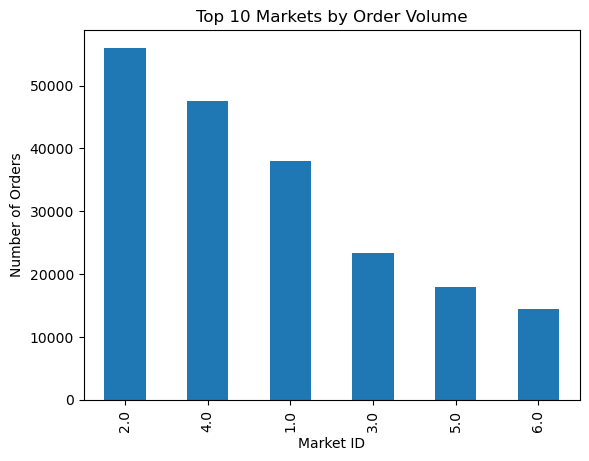

In [248]:
import matplotlib.pyplot as plt
orders_by_market.plot(kind='bar')
plt.xlabel("Market ID")
plt.ylabel("Number of Orders")
plt.title("Top 10 Markets by Order Volume")
plt.show()

#### Analysis: market ID 2 is the high demand market followed by market ID 4. Market ID 6 has least demand.

#### 2. How does the average delivery time vary between different store primary categories.

In [259]:
# average delivery time calculation
average_delivery_time = df.groupby('store_primary_category')['delivery_time'].mean().sort_values(ascending=False)

In [261]:
print(average_delivery_time)

store_primary_category
japanese    51.989905
pizza       50.811516
indian      48.867168
chinese     48.067650
dessert     48.057100
american    47.698161
Other       47.663211
burger      47.062693
sandwich    44.701180
mexican     44.489939
fast        43.817022
Name: delivery_time, dtype: float64


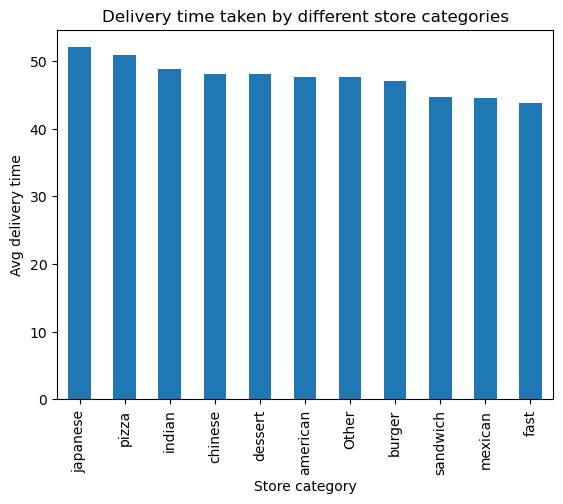

In [263]:
average_delivery_time.plot(kind='bar')
plt.xlabel('Store category')
plt.ylabel('Avg delivery time')
plt.title('Delivery time taken by different store categories')
plt.show()

#### Analysis: There is not much difference in delivery time from different store-category. So store-category is not a factor for delay in deliveries.

#### 3. What are the peak hours of order placement

In [272]:
# order by hour
orders_by_hour = df.groupby('hour_of_day').size()
print(orders_by_hour)

hour_of_day
0     12667
1     28180
2     36969
3     27068
4     15248
5      7095
6      1416
7        11
14       40
15      538
16     2109
17     3413
18     5098
19    13538
20    15554
21    11462
22     8817
23     8163
dtype: int64


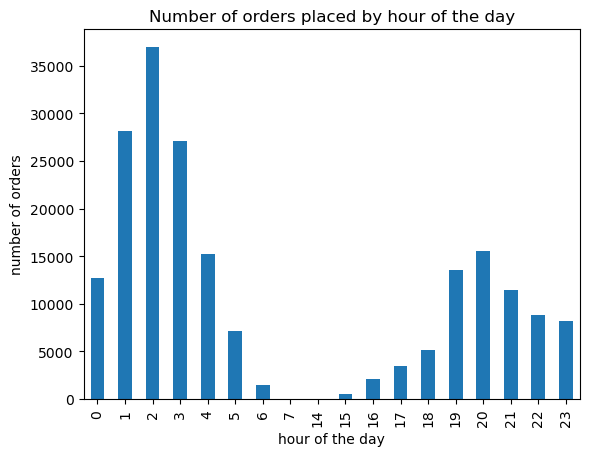

In [274]:
# visualization
orders_by_hour.plot(kind='bar')
plt.xlabel('hour of the day')
plt.ylabel('number of orders')
plt.title('Number of orders placed by hour of the day')
plt.show()

#### Analysis: 1 am to 3 am are the highest order placement period of the day. Followed by 7 pm to 9 pm having another peak order placements.

#### 4. Which days of the week sees highest order placements.

In [290]:
# orders by day
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
orders_by_day = df.groupby('day_of_week').size().reindex(week_order)

In [292]:
print(orders_by_day)

day_of_week
Monday       27397
Tuesday      24058
Wednesday    24248
Thursday     25667
Friday       27872
Saturday     34535
Sunday       33609
dtype: int64


Text(0.5, 1.0, 'Number of orders placed by day of week')

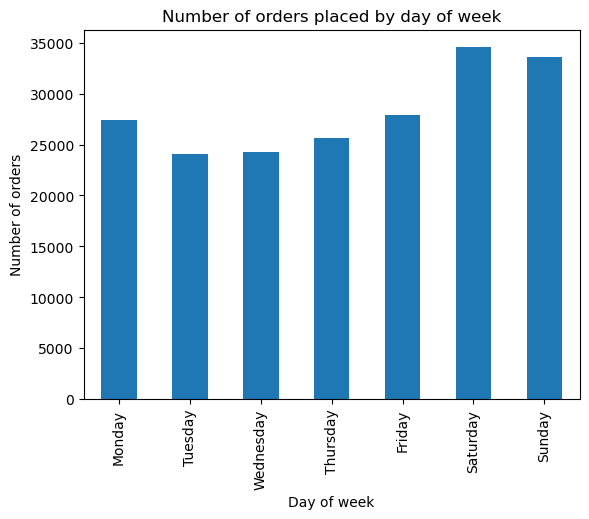

In [296]:
# visualization
orders_by_day.plot(kind='bar')
plt.xlabel('Day of week')
plt.ylabel('Number of orders')
plt.title('Number of orders placed by day of week')

#### Analysis: Saturday, Sunday and Monday are the days when most of the orders are placed.

#### 5. What is the correlation between number of items in an order and the subtotal

In [301]:
# correlation
corr = df[['total_items', 'subtotal']].corr()
print(corr)

             total_items  subtotal
total_items     1.000000  0.558049
subtotal        0.558049  1.000000


#### Analysis: Since there is no visible pattern from the scatter plot between total items and subtotal price. There is not correlation between them. The total items always remain low and price vary simply based on the item price. To simplify, subtotal does not increase when total items increase.

#### 6. Analyse the distribution of delivery times, are there notable outliers

In [308]:
# summary stats
print(df['delivery_time'].describe())


count    197386.000000
mean         47.623078
std          18.470096
min           1.683333
25%          35.066667
50%          44.333333
75%          56.350000
max         297.700000
Name: delivery_time, dtype: float64


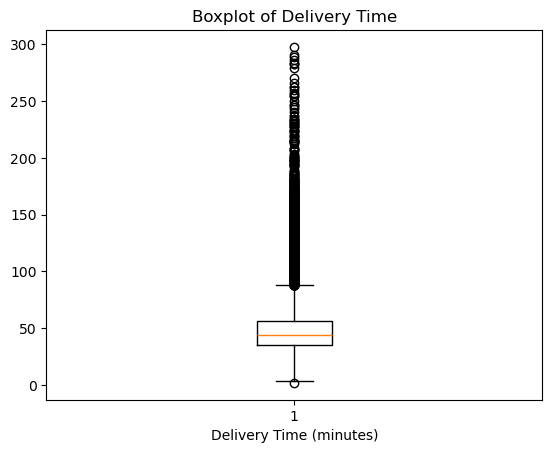

In [312]:
# boxplot (clearly shows outliers)
plt.boxplot(df['delivery_time'])
plt.xlabel("Delivery Time (minutes)")
plt.title("Boxplot of Delivery Time")
plt.show()

#### 7. What percentage of orders are delivered within 30 minutes?

In [322]:
# total orders
total_orders = len(df)


In [324]:
# orders delivered within 30 minutes
within_30 = df[df['delivery_time'] <= 30].shape[0]

In [326]:
# percentage
percentage = (within_30 / total_orders) * 100


In [328]:
print("Percentage of orders delivered within 30 minutes:", percentage)

Percentage of orders delivered within 30 minutes: 13.160001215891704


#### Analysis: Only 13.16 percentage of orders are delivered within 30 mins. This is possibly a main contributor for customer dissatisfaction.

#### 8. How do order volume correlate with number of busy partners.

In [375]:
# correlation
print(df[['total_busy_partners', 'total_outstanding_orders']].corr())

                          total_busy_partners  total_outstanding_orders
total_busy_partners                  1.000000                  0.933084
total_outstanding_orders             0.933084                  1.000000


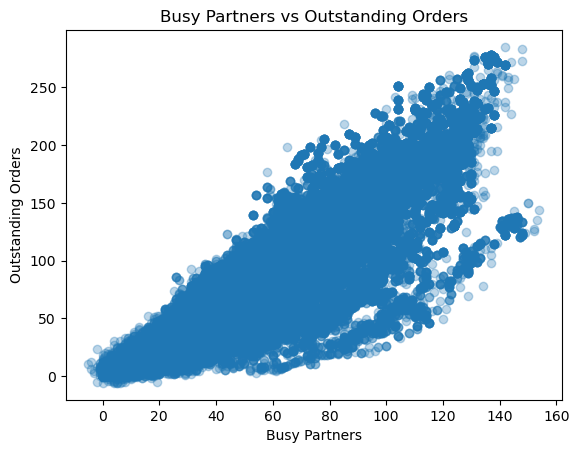

In [377]:
# scatter plot
import matplotlib.pyplot as plt
plt.scatter(df['total_busy_partners'], df['total_outstanding_orders'], alpha=0.3)
plt.xlabel("Busy Partners")
plt.ylabel("Outstanding Orders")
plt.title("Busy Partners vs Outstanding Orders")
plt.show()

#### Analysis: Its very clear from the scatter plot that the number of orders is positively related to busy partners. When order volume increases, number of busy partners increases.

#### 9. Find the relationship between available partner and delivery time.

In [401]:
# correlation with delivery time
print(df[['total_onshift_partners', 'total_busy_partners', 'delivery_time']].corr())


                        total_onshift_partners  total_busy_partners  \
total_onshift_partners                1.000000             0.944028   
total_busy_partners                   0.944028             1.000000   
delivery_time                         0.067652             0.086870   

                        delivery_time  
total_onshift_partners       0.067652  
total_busy_partners          0.086870  
delivery_time                1.000000  


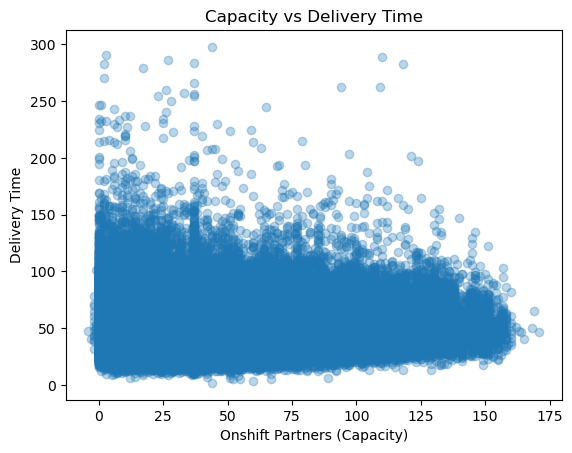

In [403]:
# scatter plots
import matplotlib.pyplot as plt

plt.scatter(df['total_onshift_partners'], df['delivery_time'], alpha=0.3)
plt.xlabel("Onshift Partners (Capacity)")
plt.ylabel("Delivery Time")
plt.title("Capacity vs Delivery Time")
plt.show()

#### Analysis: Majority of the deliveries are completed without delay when capacity is low or high. In fact we can see that when capacity is increasing delivery time is gradualy reducing. We can also see that when capacity is low delivery time has crossed 150 mark. We can conclude that to complete deliveries quickly capacity has to be high.

#### 10. 

In [409]:
# orders per hour
orders_per_hour = df.groupby('hour_of_day').size()

In [411]:
# avg delivery time per hour
delivery_time_per_hour = df.groupby('hour_of_day')['delivery_time'].mean()


In [413]:
# combine
temp = pd.DataFrame({
    'orders': orders_per_hour,
    'delivery_time': delivery_time_per_hour
})

In [415]:
# correlation
print(temp.corr())

                 orders  delivery_time
orders         1.000000       0.139256
delivery_time  0.139256       1.000000


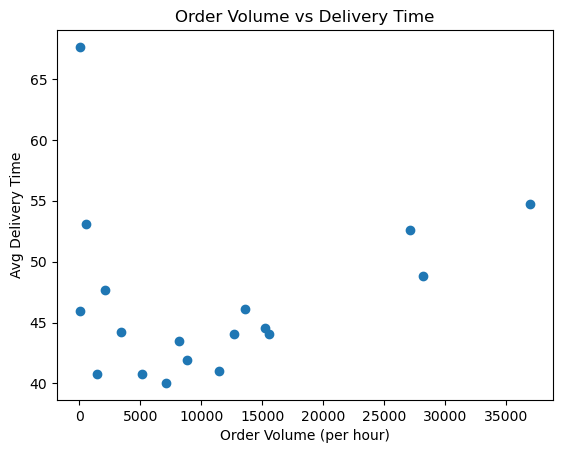

In [417]:
# plot
import matplotlib.pyplot as plt
plt.scatter(temp['orders'], temp['delivery_time'])
plt.xlabel("Order Volume (per hour)")
plt.ylabel("Avg Delivery Time")
plt.title("Order Volume vs Delivery Time")
plt.show()

In [ ]:
plt.scatter()